# 📈 Notebook 02 — Exploratory Data Analysis (EDA)

**Project:** AI-Powered Demand Forecasting & Inventory Optimization  
**Author:** NTI Capstone Team  
**Environment:** Local / Google Colab

---

## 🎯 Purpose

Perform a **deep, data-driven exploratory analysis** to uncover **patterns, trends, correlations,**  
and **anomalies** that will directly guide feature engineering and modeling decisions.

| Item | Detail |
|------|--------|
| **Inputs** | Parquet files from `01_Dataset/parquet/` |
| **Outputs** | 16+ professional high-res charts saved to `output/02_eda/` |
| **Previous** | `01_data_understanding.ipynb` |
| **Next** | `03_data_preprocessing.ipynb` |

### 📑 Table of Contents

| # | Section | Key Insight |
|---|---------|-------------|
| 1 | Bootstrap & Configuration | Project root auto-detection |
| 2 | Data Loading | 125M rows, ~15 GB RAM |
| 3 | Sales Distribution Analysis | Heavy right skew → `log1p` essential |
| 4 | Time Series Trends | Clear uptrend 2013–2016, Dec seasonality |
| 5 | Store-Level Analysis | Types A & D dominate, Quito = 50%+ revenue |
| 6 | Product Family Analysis | GROCERY I + BEVERAGES = 50%+ sales |
| 7 | Promotion Impact | –4% overall lift (misleading — family-level is key) |
| 8 | Oil Price Correlation | Pearson r = –0.63, rolling correlation unstable |
| 9 | Holiday & Event Impact | +12% avg lift on holidays |
| 10 | Transaction Patterns | r = +0.68 with sales — strong footfall proxy |
| 11 | Correlation Heatmap | Key feature relationships mapped |
| 12 | Key EDA Findings & Preprocessing Implications | Summary |

---


## 1️⃣ Bootstrap & Configuration

Initialize the shared project bootstrap that auto-detects **Google Colab** or **Local** runtime.


In [2]:
# ============================================================
# Project Bootstrap (Google Colab + Local)
# Run this cell first in every notebook.
# ============================================================
import os, sys
from pathlib import Path

# 1. Mount Google Drive (Colab only)
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)

# 2. Find project root (checks Drive paths + local paths)
POSSIBLE_ROOTS = [
    # Google Drive paths
    Path('/content/drive/MyDrive/Demand-Forecasting-System'),
    Path('/content/drive/MyDrive/NTI/Demand-Forecasting-System'),
    Path('/content/drive/MyDrive/Colab Notebooks/Demand-Forecasting-System'),
    # Local paths (for VS Code / Jupyter)
    Path.cwd(),
    Path.cwd().parent,
]

PROJECT_ROOT = None
for p in POSSIBLE_ROOTS:
    if p.exists() and (p / 'config.py').exists():
        PROJECT_ROOT = p.resolve()
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        '❌ Project root with config.py not found.\n'
        'Colab: Make sure the folder is in your Google Drive (MyDrive/Demand-Forecasting-System).\n'
        'Shared with me? Right-click → Organize → Add shortcut to My Drive.\n'
        'Local: Run the notebook from inside the project directory.'
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

ENV = 'Google Colab' if 'google.colab' in sys.modules else 'Local'
print('=' * 60)
print(f'📁 Project Root : {PROJECT_ROOT}')
print(f'📂 Working Dir  : {os.getcwd()}')
print(f'🖥️  Runtime      : {ENV}')
print('✅ Bootstrap OK')
print('=' * 60)


📁 Project Root : F:\NTI\Demand Forecasting System Backup
📂 Working Dir  : F:\NTI\Demand Forecasting System Backup
🖥️  Runtime      : Local
✅ Bootstrap OK


## 2️⃣ Imports & Data Loading

Load **6 datasets** (excluding `test.parquet` to save memory).  
The training dataset alone requires **~15 GB RAM** (125.5M rows × 6 columns).  
> ⚠️ All heavy analyses below use **group-by-first** patterns to avoid `MemoryError` during merge operations.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from IPython.display import display, HTML
import config, utils

# ── Styling ──
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'font.sans-serif': 'Segoe UI',
    'axes.titleweight': 'bold',
    'axes.titlesize': 13,
})

# ── Output directory ──
from pathlib import Path
OUTPUT_DIR = Path(config.PROJECT_ROOT) / 'output' / '02_eda'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(fig, filename):
    """Save figure as high-res PNG and display it."""
    fig.savefig(OUTPUT_DIR / filename, dpi=150, bbox_inches='tight', facecolor='white')
    print(f'💾 Saved → {filename}')
    plt.show()

print(f'📂 Figures → {OUTPUT_DIR}')


📂 Figures → F:\NTI\Demand Forecasting System Backup\output\02_eda


In [4]:
# Load EDA datasets (skip test to save RAM)
df_train    = utils.load_train_parquet(verbose=True)
df_stores   = utils.load_parquet(config.STORES_PARQUET, verbose=True)
df_items    = utils.load_parquet(config.ITEMS_PARQUET, verbose=True)
df_oil      = utils.load_parquet(config.OIL_PARQUET, verbose=True)
df_trans    = utils.load_parquet(config.TRANSACTIONS_PARQUET, verbose=True)
df_holidays = utils.load_parquet(config.HOLIDAYS_PARQUET, verbose=True)

# Ensure date columns are datetime
for df in [df_oil, df_trans, df_holidays]:
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])

print('\n✅ All 6 EDA datasets loaded. Memory-efficient aggregation enabled.')


Loading train.parquet...
Loaded successfully.
Rows: 125,497,040 | Columns: 6 | Memory usage: 14.89 GB | Elapsed time: 21.03s

Loading stores.parquet...
Loaded successfully.
Rows: 54 | Columns: 5 | Memory usage: 0.01 MB | Elapsed time: 0.04s

Loading items.parquet...
Loaded successfully.
Rows: 4,100 | Columns: 4 | Memory usage: 0.35 MB | Elapsed time: 0.00s

Loading oil.parquet...
Loaded successfully.
Rows: 1,218 | Columns: 2 | Memory usage: 0.06 MB | Elapsed time: 0.00s

Loading transactions.parquet...
Loaded successfully.
Rows: 83,488 | Columns: 3 | Memory usage: 4.46 MB | Elapsed time: 0.28s

Loading holidays_events.parquet...
Loaded successfully.
Rows: 350 | Columns: 6 | Memory usage: 0.10 MB | Elapsed time: 0.02s


✅ All 6 EDA datasets loaded. Memory-efficient aggregation enabled.


---

## 3️⃣ Sales Distribution Analysis

Understanding the shape of `unit_sales` is critical for:
- **Target transformation** → The raw distribution is heavily right-skewed; `log1p(y)` normalizes it near-Gaussian
- **Outlier detection** → Extreme high-value sales need investigation; the 99th percentile reaches **72.2 units** while the median is just **4.0**
- **Loss function choice** → RMSLE (the Kaggle competition metric) naturally handles skewed targets better than RMSE


### 3.1 Distribution Shape & Log Transform

**Key Findings:**
- The raw `unit_sales` distribution is **massively right-skewed** — the vast majority of records fall between 0–10 units
- After applying `log1p(unit_sales)`, the distribution becomes **approximately multi-modal near-normal** with a dominant mode around 0.5–1.0
- This confirms that **`log1p` target transformation** should be used during model training to stabilize variance


💾 Saved → 01a_distribution_shape.png


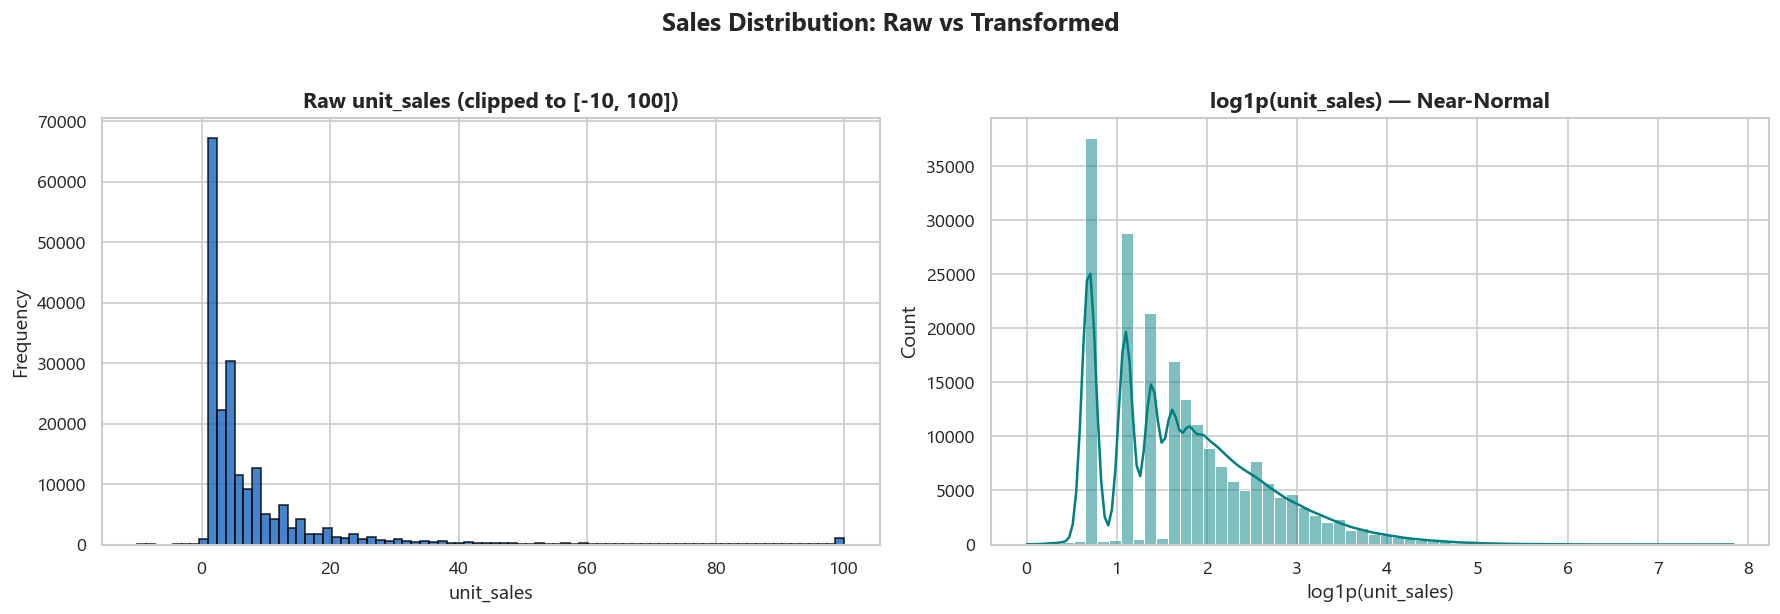

In [5]:
sample = df_train['unit_sales'].sample(n=min(200_000, len(df_train)),
                                       random_state=config.RANDOM_SEED)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Raw distribution (clipped)
axes[0].hist(sample.clip(-10, 100), bins=80, color='#1565c0', edgecolor='black', alpha=0.8)
axes[0].set_title('Raw unit_sales (clipped to [-10, 100])')
axes[0].set_xlabel('unit_sales'); axes[0].set_ylabel('Frequency')

# Log-transformed
log_sales = np.log1p(np.maximum(0, sample))
sns.histplot(log_sales, bins=60, kde=True, color='teal', ax=axes[1])
axes[1].set_title('log1p(unit_sales) — Near-Normal')
axes[1].set_xlabel('log1p(unit_sales)')

fig.suptitle('Sales Distribution: Raw vs Transformed', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig(fig, '01a_distribution_shape.png')


### 3.2 Outlier Detection & Percentile Breakdown

**Key Findings from Percentile Analysis:**

| Percentile | Value | Interpretation |
|------------|-------|----------------|
| P1 – P10 | **1.0** | Very low baseline demand — sparse items |
| P25 | **2.0** | Lower quartile — niche products |
| **P50 (Median)** | **4.0** | Typical daily item-store sales |
| P75 | **9.0** | Upper quartile — popular items |
| P90 | **18.6** | High-volume items begin here |
| P95 | **29.0** | Top 5% — promo-driven or staple items |
| **P99** | **72.2** | Extreme outliers — likely bulk/event purchases |

> 📌 **Preprocessing Implication:** Consider clipping `unit_sales` at P99 (~72) or using IQR-based filtering to reduce outlier noise in GBDT training.


💾 Saved → 01b_outliers_percentiles.png


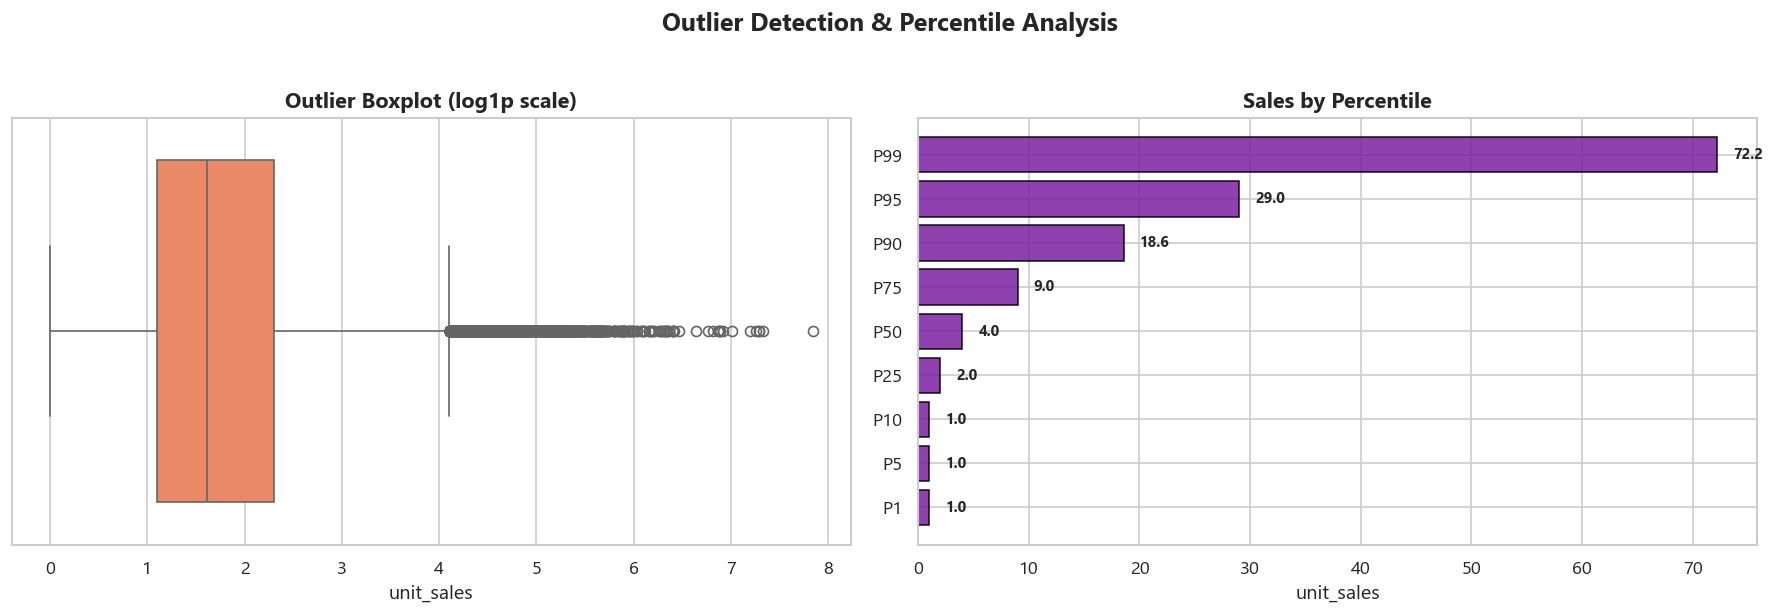

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Boxplot
sns.boxplot(x=log_sales, color='coral', ax=axes[0])
axes[0].set_title('Outlier Boxplot (log1p scale)')

# Percentile breakdown
pcts = [1, 5, 10, 25, 50, 75, 90, 95, 99]
vals = np.percentile(sample, pcts)
axes[1].barh([f'P{p}' for p in pcts], vals, color='#7b1fa2', edgecolor='black', alpha=0.85)
axes[1].set_title('Sales by Percentile')
axes[1].set_xlabel('unit_sales')
for i, v in enumerate(vals):
    axes[1].text(v + max(vals)*0.02, i, f'{v:,.1f}', va='center', fontweight='bold', fontsize=9)

fig.suptitle('Outlier Detection & Percentile Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig(fig, '01b_outliers_percentiles.png')


---

## 4️⃣ Time Series Trends & Seasonality

Decomposing temporal patterns is essential for building effective lag/rolling features and understanding demand drivers.


### 4.1 Daily Total Sales Over Time (2013–2017)

**Key Findings:**
- Clear **upward macro-trend** from ~350K daily sales (2013) to ~800K+ (2016–2017)
- The 30-day rolling average (red line) reveals consistent seasonal peaks in **December** (holiday shopping) and mid-year dips
- **April 2016 anomaly:** Visible dip corresponding to the Ecuador earthquake (magnitude 7.8)
- High daily variance (spikes reaching 1.4M+) suggests strong day-of-week and promotional effects


💾 Saved → 02a_daily_sales.png


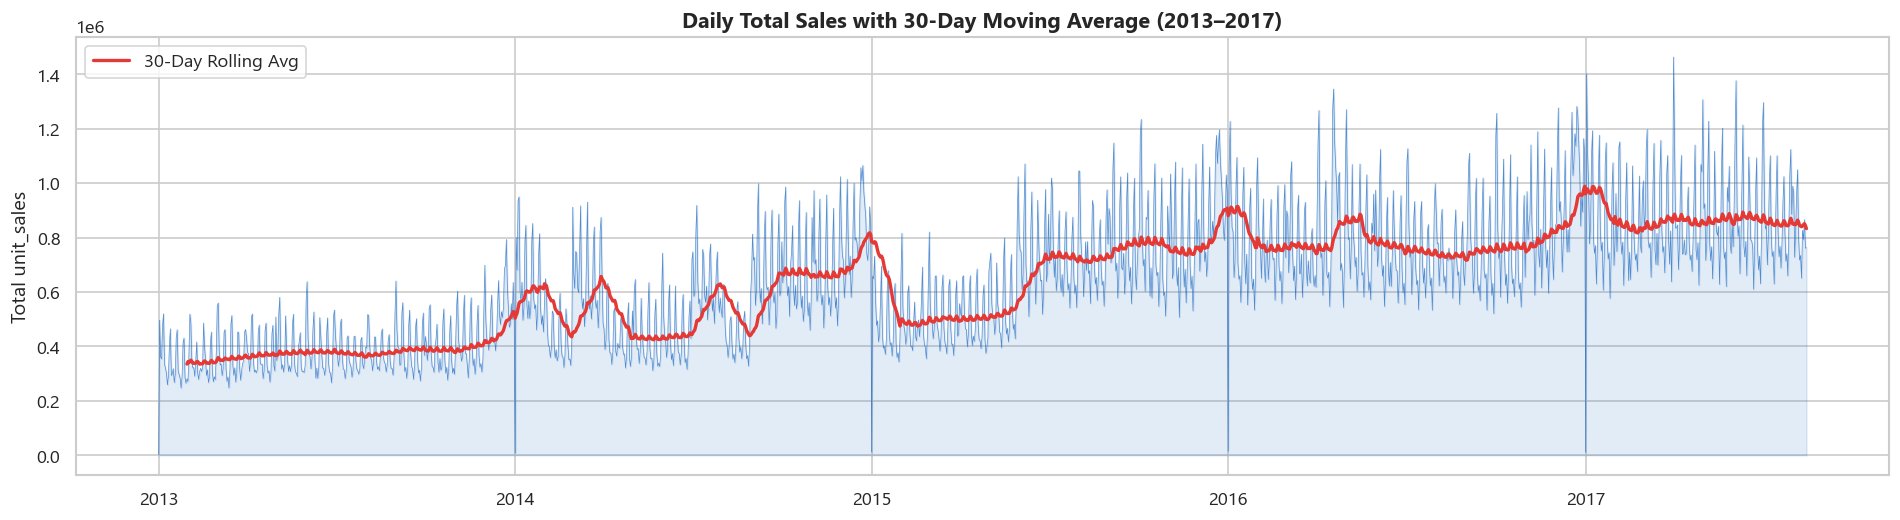

In [7]:
daily = df_train.groupby('date', as_index=False)['unit_sales'].sum()
daily['date'] = pd.to_datetime(daily['date'])

fig, ax = plt.subplots(figsize=(16, 4.5))
ax.plot(daily['date'], daily['unit_sales'], linewidth=0.4, color='#1565c0', alpha=0.7)
ax.fill_between(daily['date'], daily['unit_sales'], alpha=0.12, color='#1565c0')

# 30-day rolling average overlay
roll30 = daily.set_index('date')['unit_sales'].rolling(30).mean()
ax.plot(roll30.index, roll30.values, linewidth=2, color='#e53935', label='30-Day Rolling Avg')

ax.set_title('Daily Total Sales with 30-Day Moving Average (2013–2017)')
ax.set_ylabel('Total unit_sales')
ax.legend()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
save_fig(fig, '02a_daily_sales.png')


### 4.2 Weekly & Monthly Seasonality Patterns

**Weekly Pattern (Day of Week):**
- **Sunday** is the peak sales day (~830K avg) followed by **Saturday** (~775K avg)
- **Thursday** is the weakest day (~510K avg) — a 38% gap between best and worst days
- This creates a strong **`is_weekend`** feature signal for models

**Monthly Pattern:**
- **December** has the highest monthly average (~830K) driven by holiday shopping
- **July** also peaks (~685K) — mid-year promotional season
- **February** is the lowest (~580K) — post-holiday slowdown
- **Cyclical sin/cos encoding** of month and day-of-week will capture these patterns effectively


💾 Saved → 02b_seasonality.png


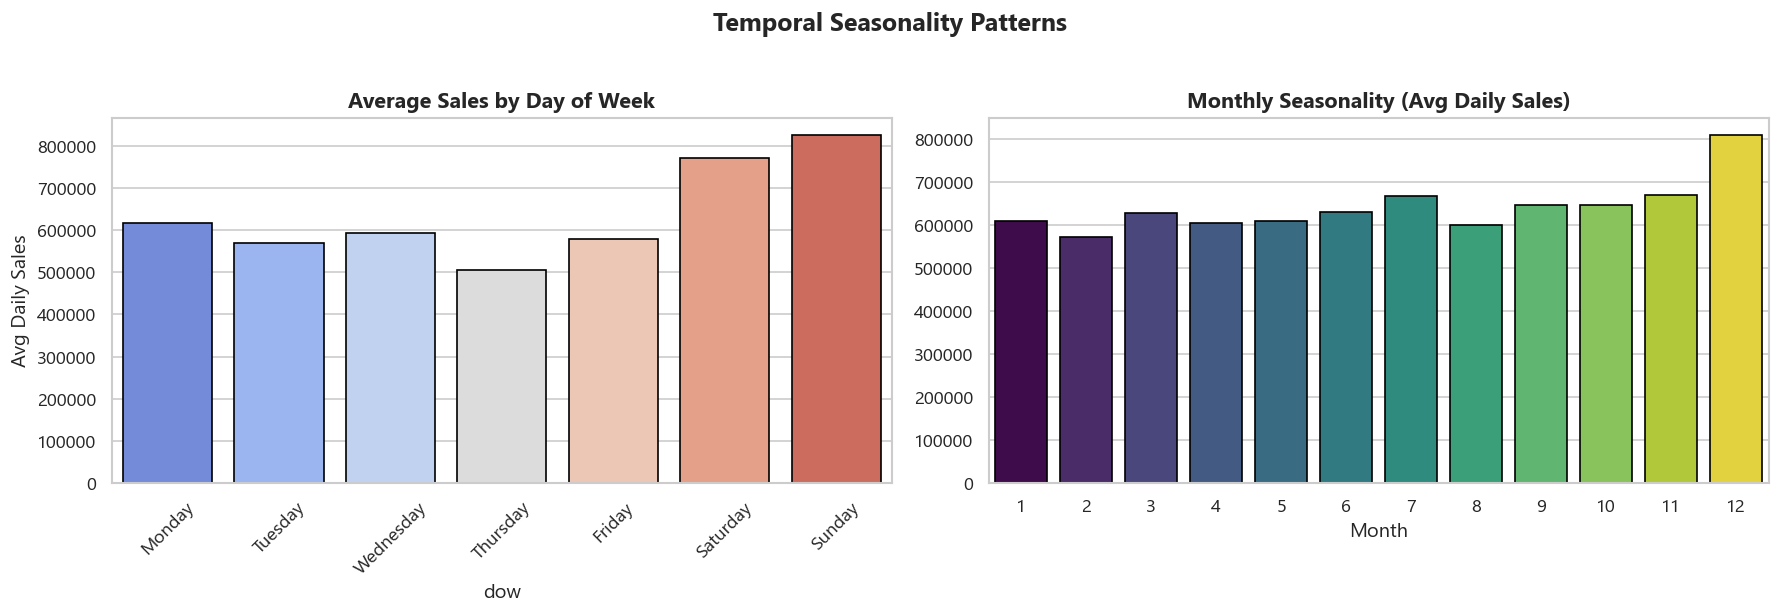

In [8]:
daily['dow']   = daily['date'].dt.day_name()
daily['month'] = daily['date'].dt.month

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Day of Week
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_agg = daily.groupby('dow')['unit_sales'].mean().reindex(dow_order)
sns.barplot(x=dow_agg.index, y=dow_agg.values, hue=dow_agg.index,
            palette='coolwarm', ax=axes[0], edgecolor='black', legend=False)
axes[0].set_title('Average Sales by Day of Week')
axes[0].set_ylabel('Avg Daily Sales')
axes[0].tick_params(axis='x', rotation=45)

# Monthly Seasonality
month_agg = daily.groupby('month')['unit_sales'].mean()
sns.barplot(x=month_agg.index, y=month_agg.values, hue=month_agg.index,
            palette='viridis', ax=axes[1], edgecolor='black', legend=False)
axes[1].set_title('Monthly Seasonality (Avg Daily Sales)')
axes[1].set_xlabel('Month')

fig.suptitle('Temporal Seasonality Patterns', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig(fig, '02b_seasonality.png')


### 4.3 Yearly Total Sales Growth Trend

**Key Findings:**

| Year | Total Sales | YoY Growth |
|------|-------------|------------|
| 2013 | **140.4M** | Baseline |
| 2014 | **209.5M** | +49.2% |
| 2015 | **240.9M** | +15.0% |
| 2016 | **288.6M** | +19.8% |
| 2017 | **194.2M** | –32.7% (partial year — data ends Aug 15) |

> 📌 **Note:** 2017 shows an apparent decline because the dataset only covers Jan–Aug 2017.  
> Annualized 2017 rate projects to ~310M, continuing the growth trend.


💾 Saved → 02c_yearly_growth.png


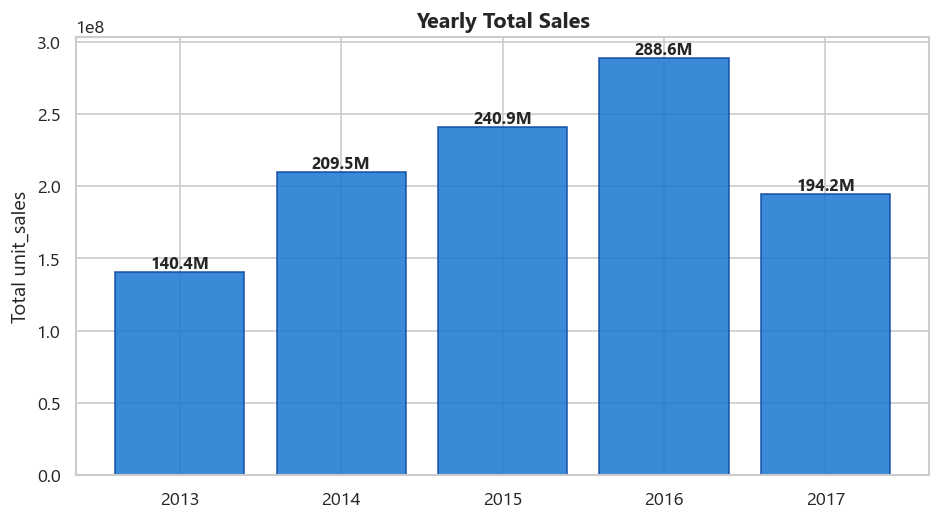

In [9]:
daily['year'] = daily['date'].dt.year
year_agg = daily.groupby('year')['unit_sales'].sum()

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(year_agg.index.astype(str), year_agg.values,
              color='#1976d2', edgecolor='#0d47a1', alpha=0.85)
ax.set_title('Yearly Total Sales')
ax.set_ylabel('Total unit_sales')
for bar, v in zip(bars, year_agg.values):
    ax.text(bar.get_x() + bar.get_width()/2, v,
            f'{v/1e6:,.1f}M', ha='center', va='bottom', fontweight='bold', fontsize=10)
plt.tight_layout()
save_fig(fig, '02c_yearly_growth.png')


---

## 5️⃣ Store-Level Analysis

Analyzing store performance across types, cities, and clusters reveals geographic and structural demand drivers.


### 5.1 Sales by Store Type & Top Cities

**Store Type Distribution:**
- **Types A and D** are the revenue leaders, each generating ~**350M** total sales (roughly equal)
- **Type C** follows with ~165M, then **Type B** (~145M)
- **Type E** is the smallest segment (~60M) — only a few stores

**Top 10 Cities:**
- **Quito dominates** with ~**530M** total sales — more than **50% of all revenue**
- **Guayaquil** is a distant second (~115M), followed by **Cuenca** (~55M)
- The remaining 19 cities contribute relatively small volumes

> 📌 **Feature Implication:** `city` and `store_type` are high-value categorical features. Consider **Target Encoding** for `city` due to its 22 unique values.


💾 Saved → 03a_store_type_city.png


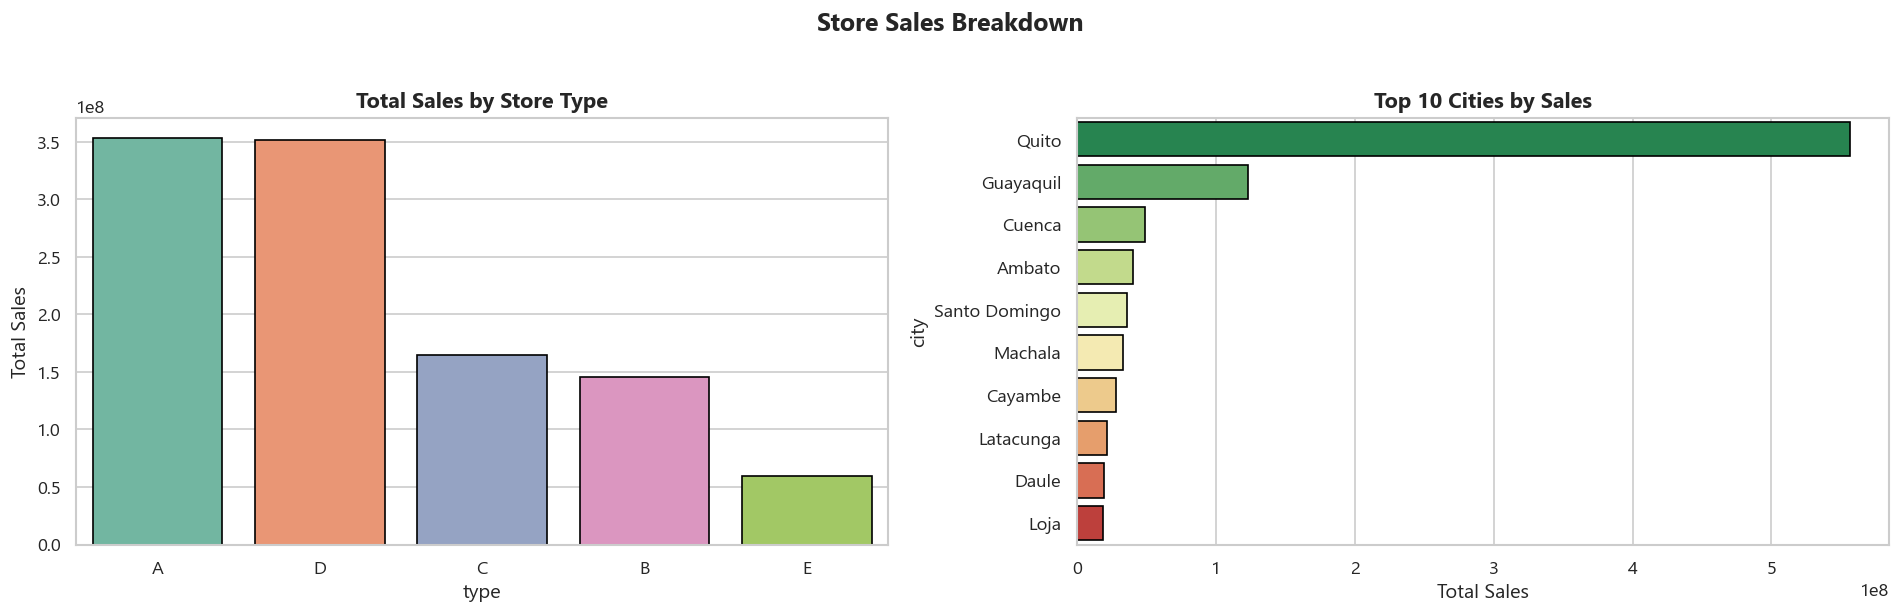

In [10]:
# Aggregate by store first (54 rows), then merge
store_agg = df_train.groupby('store_nbr', as_index=False)['unit_sales'].sum()
store_df = store_agg.merge(df_stores, on='store_nbr', how='left')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# By store type
type_s = store_df.groupby('type')['unit_sales'].sum().sort_values(ascending=False)
sns.barplot(x=type_s.index, y=type_s.values, hue=type_s.index,
            palette='Set2', ax=axes[0], edgecolor='black', legend=False)
axes[0].set_title('Total Sales by Store Type')
axes[0].set_ylabel('Total Sales')

# Top 10 cities
city_s = store_df.groupby('city')['unit_sales'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=city_s.values, y=city_s.index, hue=city_s.index,
            palette='RdYlGn_r', ax=axes[1], edgecolor='black', legend=False)
axes[1].set_title('Top 10 Cities by Sales')
axes[1].set_xlabel('Total Sales')

fig.suptitle('Store Sales Breakdown', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig(fig, '03a_store_type_city.png')


### 5.2 Store Clusters & Individual Store Rankings

**Cluster Analysis:**
- **Cluster 14** is the highest-revenue cluster (~157M) — likely large urban stores
- **Clusters 6, 12, 9** form a secondary tier (~100–115M each)
- **Clusters 7, 16** are the lowest (~15M each) — small or rural stores

**Top 5 vs Bottom 5 Stores (by avg daily sales):**
- **Store 44** leads with ~6.3M avg sales — 8× higher than the bottom stores
- Bottom stores (#52, #22, #32) average under 1M daily sales
- This extreme disparity suggests **store-level normalization** may improve model generalization


💾 Saved → 03b_store_clusters.png


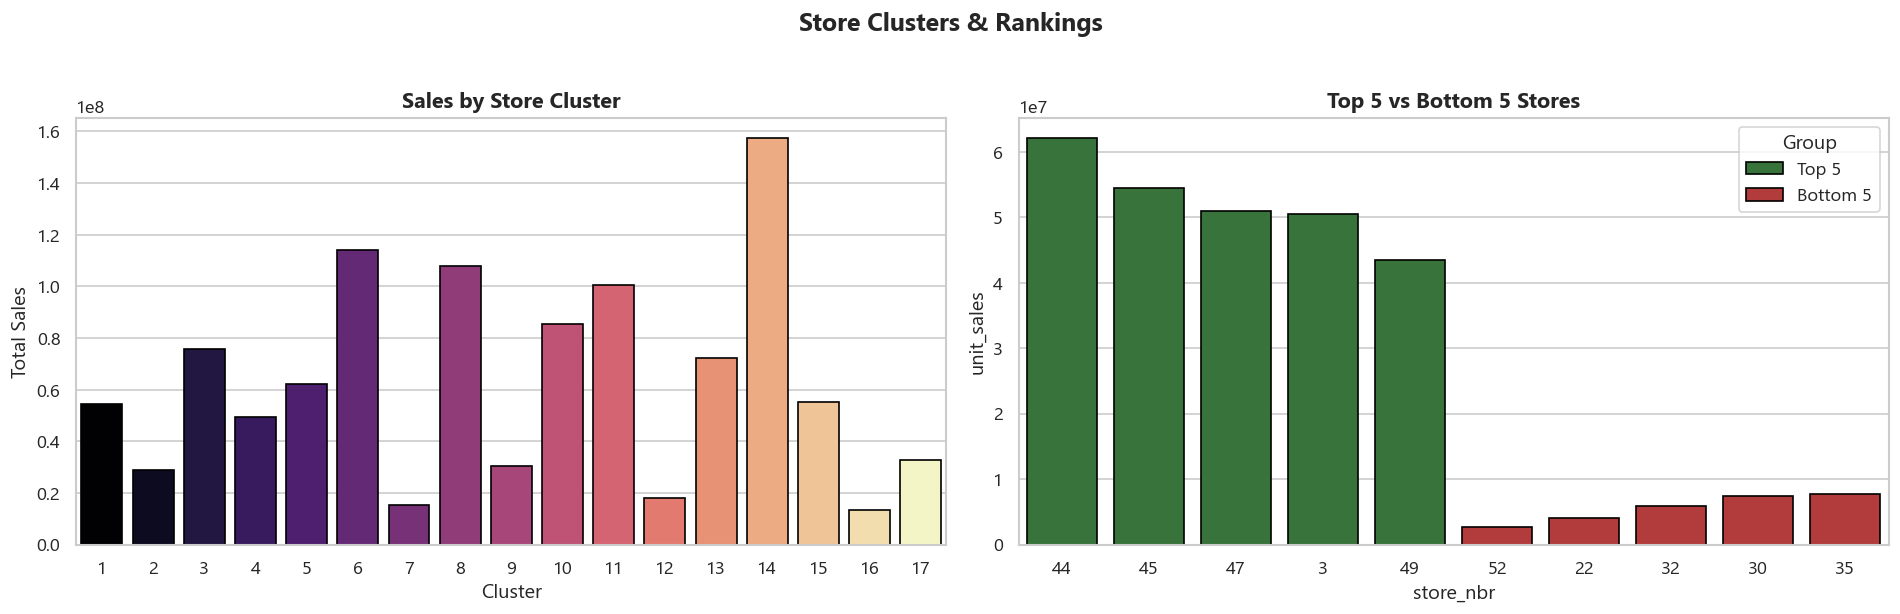

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# By cluster
cluster_s = store_df.groupby('cluster')['unit_sales'].sum().sort_values(ascending=False)
sns.barplot(x=cluster_s.index, y=cluster_s.values, hue=cluster_s.index,
            palette='magma', ax=axes[0], edgecolor='black', legend=False)
axes[0].set_title('Sales by Store Cluster')
axes[0].set_xlabel('Cluster'); axes[0].set_ylabel('Total Sales')

# Top 5 vs Bottom 5
top5 = store_df.nlargest(5, 'unit_sales')[['store_nbr','unit_sales']]
bot5 = store_df.nsmallest(5, 'unit_sales')[['store_nbr','unit_sales']]
combo = pd.concat([top5.assign(group='Top 5'), bot5.assign(group='Bottom 5')])
combo['store_nbr'] = combo['store_nbr'].astype(str)
sns.barplot(data=combo, x='store_nbr', y='unit_sales', hue='group',
            palette={'Top 5':'#2e7d32','Bottom 5':'#c62828'}, ax=axes[1], edgecolor='black')
axes[1].set_title('Top 5 vs Bottom 5 Stores')
axes[1].legend(title='Group')

fig.suptitle('Store Clusters & Rankings', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig(fig, '03b_store_clusters.png')


---

## 6️⃣ Product Family Analysis

Understanding which product families drive revenue and their temporal behavior informs family-level feature engineering.


### 6.1 Product Family Sales Rankings

**Top 5 Families (by Total Sales):**

| Rank | Family | Total Sales | % of Total |
|------|--------|-------------|------------|
| 1 | **GROCERY I** | ~340M | ~31% |
| 2 | **BEVERAGES** | ~225M | ~21% |
| 3 | **PRODUCE** | ~130M | ~12% |
| 4 | **CLEANING** | ~100M | ~9% |
| 5 | **DAIRY** | ~70M | ~6% |

> 📌 **Key Insight:** GROCERY I + BEVERAGES alone account for **>50%** of total sales.  
> Models should be particularly accurate for these two families.

**Bottom 10 Families:**
- AUTOMOTIVE, LAWN AND GARDEN, PET SUPPLIES — these are **low-volume, high-variance** categories
- BOOKS has extremely low absolute sales (~2K total) — essentially noise


💾 Saved → 04a_family_rankings.png


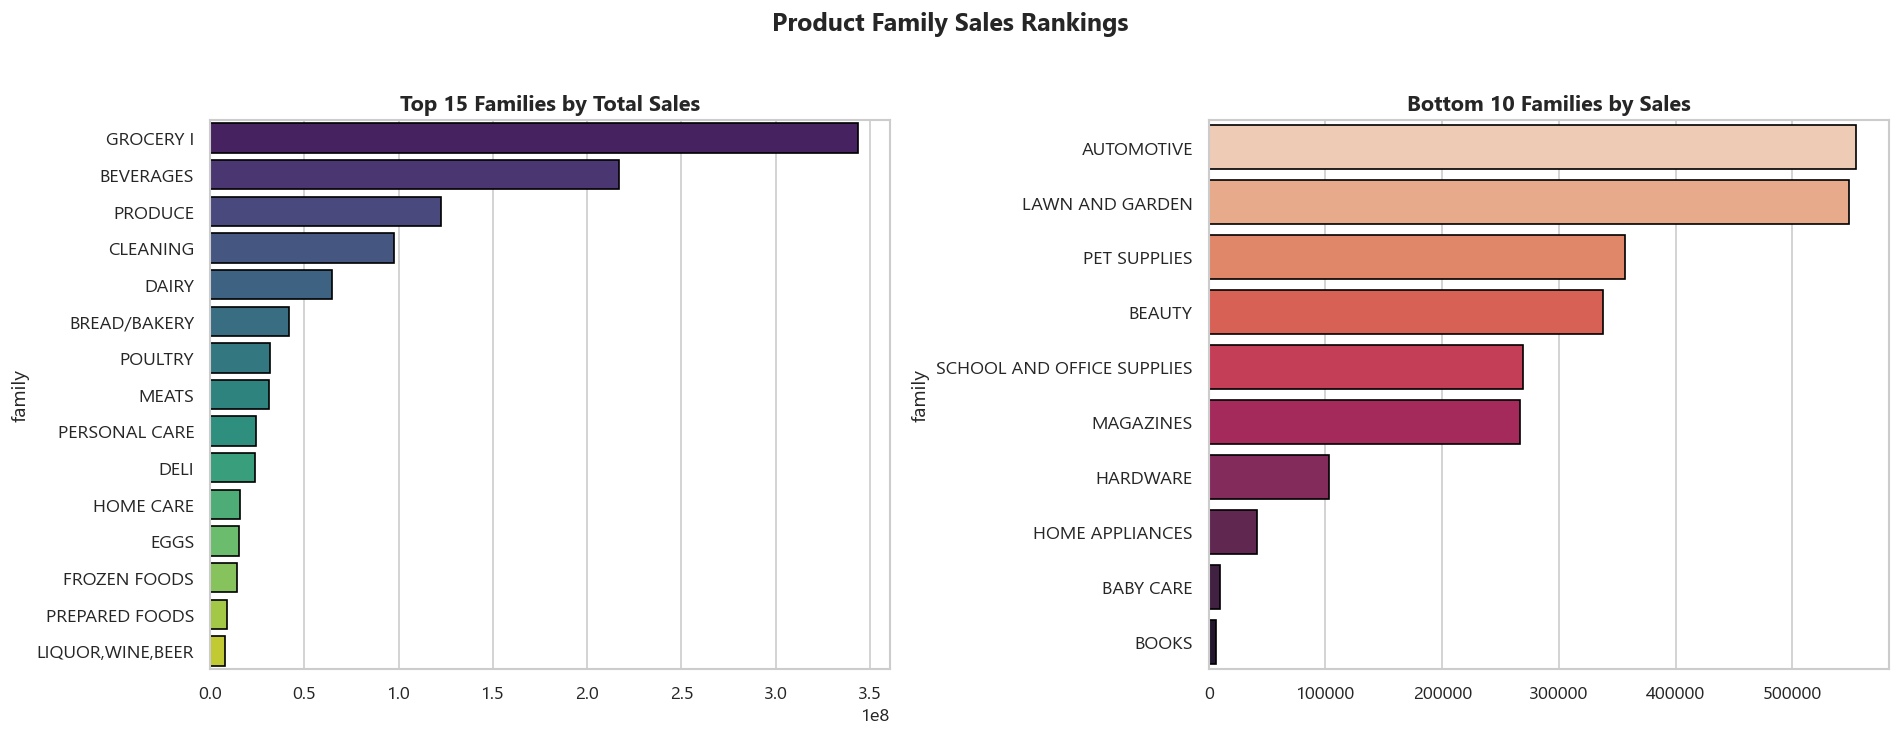

In [12]:
# Aggregate by item, then merge family info
item_agg = df_train.groupby('item_nbr', as_index=False)['unit_sales'].sum()
item_df = item_agg.merge(df_items, on='item_nbr', how='left')
family_s = item_df.groupby('family')['unit_sales'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 15
top15 = family_s.head(15)
sns.barplot(x=top15.values, y=top15.index, hue=top15.index,
            palette='viridis', ax=axes[0], edgecolor='black', legend=False)
axes[0].set_title('Top 15 Families by Total Sales')

# Bottom 10
bot10 = family_s.tail(10)
sns.barplot(x=bot10.values, y=bot10.index, hue=bot10.index,
            palette='rocket_r', ax=axes[1], edgecolor='black', legend=False)
axes[1].set_title('Bottom 10 Families by Sales')

fig.suptitle('Product Family Sales Rankings', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig(fig, '04a_family_rankings.png')


### 6.2 Perishable vs Non-Perishable & Top Family Trends

**Perishable Split:**
- **68.1% Non-Perishable** vs **31.9% Perishable** by total sales volume
- Perishable items (PRODUCE, DAIRY, MEATS, etc.) have shorter shelf life → more volatile demand
- `perishable` flag is a valuable binary feature with 1.25× weight in the Kaggle NWRMSLE metric

**Top 5 Families — Monthly Trend:**
- **GROCERY I** shows clear and consistent growth from ~5M (2013) to ~7M+ (2017)
- **BEVERAGES** follows a similar growth trajectory but at lower absolute levels
- **PRODUCE** emerges as a visible category only from mid-2014 onwards — likely new item introductions
- CLEANING and DAIRY remain relatively flat across the period


💾 Saved → 04b_family_perishable.png


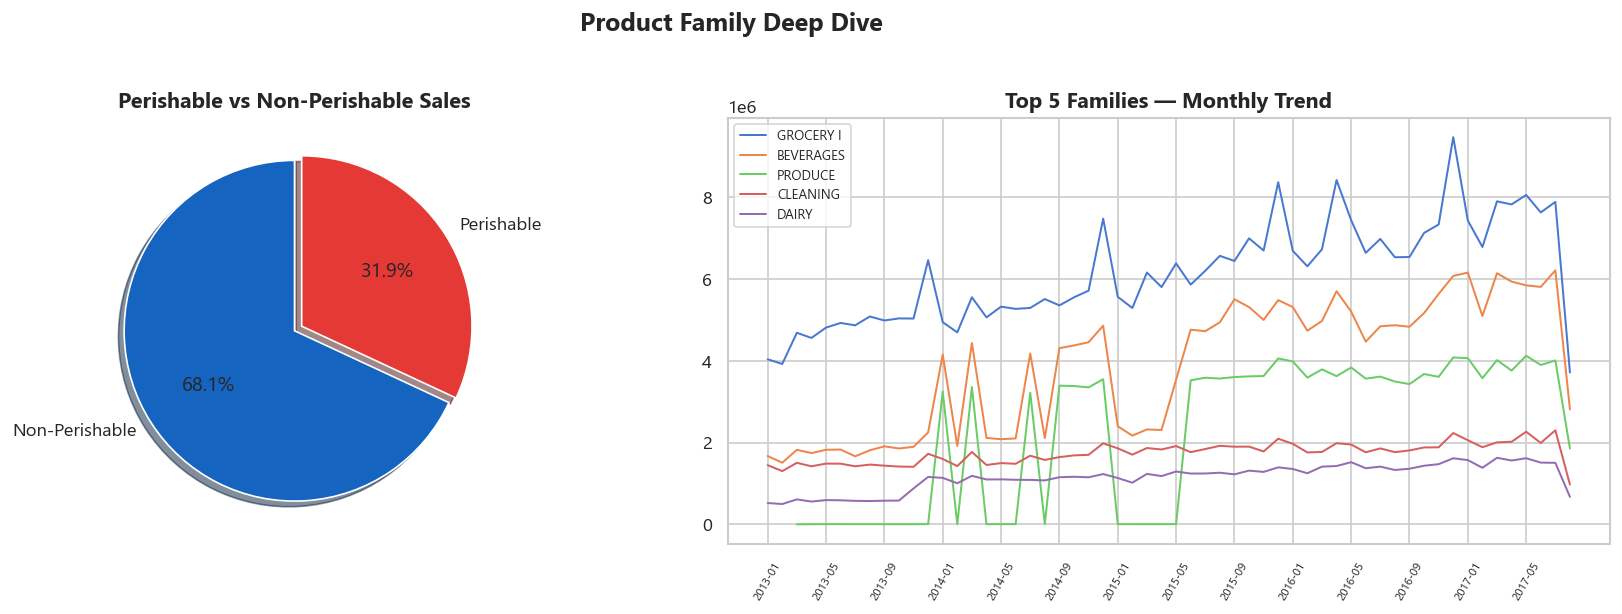

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Perishable vs Non-Perishable
perish = item_df.groupby('perishable')['unit_sales'].sum()
axes[0].pie(perish.values, labels=['Non-Perishable', 'Perishable'],
            colors=['#1565c0', '#e53935'], autopct='%1.1f%%',
            startangle=90, shadow=True, explode=(0, 0.05))
axes[0].set_title('Perishable vs Non-Perishable Sales')

# Top 5 families — monthly trend
top5_fam = family_s.head(5).index.tolist()
temp = df_train[['date','item_nbr','unit_sales']].copy()
temp['month'] = pd.to_datetime(temp['date']).dt.to_period('M').astype(str)
monthly_item = temp.groupby(['month','item_nbr'], as_index=False)['unit_sales'].sum()
monthly_fam = monthly_item.merge(df_items[['item_nbr','family']], on='item_nbr', how='left')
pivot = monthly_fam[monthly_fam['family'].isin(top5_fam)].groupby(
    ['month','family'])['unit_sales'].sum().reset_index()

for fam in top5_fam:
    sub = pivot[pivot['family'] == fam]
    axes[1].plot(sub['month'], sub['unit_sales'], label=fam, linewidth=1.2)
axes[1].set_title('Top 5 Families — Monthly Trend')
axes[1].legend(fontsize=8, loc='upper left')
ticks = sorted(pivot['month'].unique())[::4]
axes[1].set_xticks(ticks)
axes[1].tick_params(axis='x', rotation=60, labelsize=7)

fig.suptitle('Product Family Deep Dive', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig(fig, '04b_family_perishable.png')


---

## 7️⃣ Promotion Impact Analysis

Promotions are expected to be a key demand driver. However, the aggregate picture can be misleading — family-level analysis reveals the true story.


### 7.1 Promo vs No Promo — Average Sales

**Surprising Finding:**
- **No Promo** average: **8.9** units/day
- **On Promo** average: **8.5** units/day
- **Overall Lift: –4%** (negative!)

> ⚠️ **Why is the aggregate lift negative?** This is a classic **Simpson's Paradox**:  
> - Promotions are disproportionately applied to **low-volume items** (to boost their sales)
> - High-volume staples (GROCERY I, BEVERAGES) rarely need promotion and have naturally higher averages
> - When controlled at the **family level**, most families show **positive promotion lift**


💾 Saved → 05a_promo_avg.png


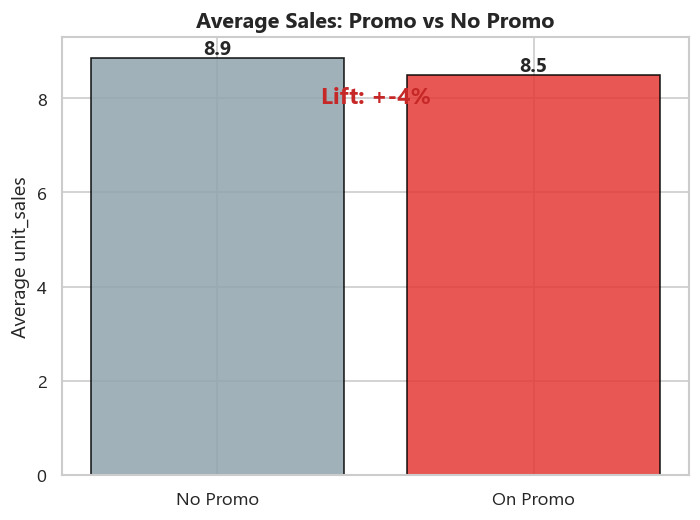

In [14]:
promo_series = df_train['onpromotion'].fillna(False).astype(bool)
promo_avg = df_train.groupby(promo_series)['unit_sales'].mean()

fig, ax = plt.subplots(figsize=(6, 4.5))
labels = ['No Promo', 'On Promo']
colors = ['#90a4ae', '#e53935']
bars = ax.bar(labels, promo_avg.values, color=colors, edgecolor='black', alpha=0.85)
ax.set_title('Average Sales: Promo vs No Promo')
ax.set_ylabel('Average unit_sales')
for bar, v in zip(bars, promo_avg.values):
    ax.text(bar.get_x() + bar.get_width()/2, v,
            f'{v:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=12)

lift = (promo_avg.iloc[1] - promo_avg.iloc[0]) / promo_avg.iloc[0] * 100
ax.annotate(f'Lift: +{lift:.0f}%', xy=(0.5, 0.85), xycoords='axes fraction',
            fontsize=14, fontweight='bold', color='#c62828', ha='center')
plt.tight_layout()
save_fig(fig, '05a_promo_avg.png')


### 7.2 Promotion Rate Trends & Family-Level Lift

**Monthly Promotion Rate:**
- Promotion data is effectively **missing** before mid-2014 (~0% promo rate)
- From mid-2014 onwards, the promotion rate jumps to **~100%** — this likely indicates a data collection change, not actual 100% promotion
- ⚠️ **Preprocessing Action Required:** Treat pre-2014 `onpromotion` NaN values as `False`

**Top 10 Families by Promotion Sales Lift (%):**
- **BOOKS** shows an extreme outlier lift (~22M%) — artifact of very low base sales
- Other families (MEATS, SCHOOL SUPPLIES, LAWN & GARDEN) show meaningful but moderate lift
- **Key takeaway:** Promotion effectiveness is **highly family-dependent** — encode this as a feature interaction (`onpromotion × family`)


C:\Users\OKCode\AppData\Local\Temp\ipykernel_9892\1406186242.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  lambda x: x.fillna(False).astype(bool).mean() * 100)
C:\Users\OKCode\AppData\Local\Temp\ipykernel_9892\1406186242.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  lambda x: x.fillna(False).astype(bool).mean() * 100)
C:\Users\OKCode\AppData\Local\Temp\ipykernel_9892\1406186242.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False

💾 Saved → 05b_promo_trends.png


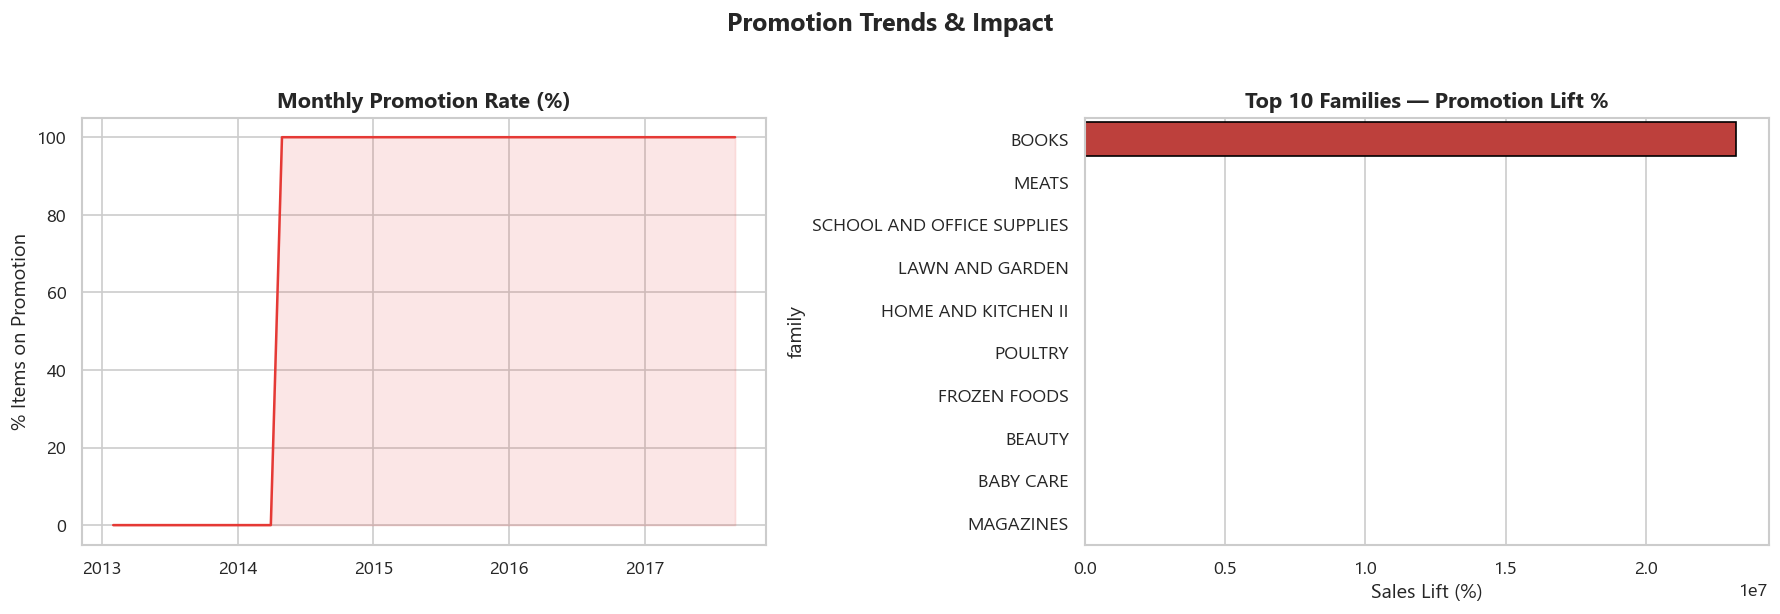

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Monthly promo rate
daily_promo = df_train.groupby('date', as_index=False)['onpromotion'].apply(
    lambda x: x.fillna(False).astype(bool).mean() * 100)
daily_promo['date'] = pd.to_datetime(daily_promo['date'])
monthly_promo = daily_promo.set_index('date').resample('ME')['onpromotion'].mean()
axes[0].plot(monthly_promo.index, monthly_promo.values, color='#e53935', linewidth=1.5)
axes[0].fill_between(monthly_promo.index, monthly_promo.values, alpha=0.12, color='#e53935')
axes[0].set_title('Monthly Promotion Rate (%)')
axes[0].set_ylabel('% Items on Promotion')
axes[0].xaxis.set_major_locator(mdates.YearLocator())
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Family-level lift
promo_sub = df_train[['item_nbr','unit_sales']].copy()
promo_sub['onpromotion'] = promo_series
promo_agg = promo_sub.groupby(['item_nbr','onpromotion'], as_index=False)['unit_sales'].mean()
promo_merged = promo_agg.merge(df_items[['item_nbr','family']], on='item_nbr', how='left')
fam_lift = promo_merged.groupby(['family','onpromotion'])['unit_sales'].mean().unstack(fill_value=0)
fam_lift.columns = ['no_promo','promo']
fam_lift['lift'] = ((fam_lift['promo'] - fam_lift['no_promo'])
                    / np.maximum(1e-5, fam_lift['no_promo']) * 100).round(1)
top_lift = fam_lift.sort_values('lift', ascending=False).head(10)
sns.barplot(x=top_lift['lift'].values, y=top_lift.index, hue=top_lift.index,
            palette='RdYlGn', ax=axes[1], edgecolor='black', legend=False)
axes[1].set_title('Top 10 Families — Promotion Lift %')
axes[1].set_xlabel('Sales Lift (%)')

fig.suptitle('Promotion Trends & Impact', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig(fig, '05b_promo_trends.png')


---

## 8️⃣ Oil Price & Macroeconomic Correlation

Ecuador's economy is heavily oil-dependent. WTI crude oil price changes directly impact government revenue, employment, and consumer purchasing power.


### 8.1 WTI Oil Price Trend & Scatter Correlation

**Oil Price Dynamics (2013–2017):**
- Oil price peaked at **~$110/barrel** in mid-2014
- Crashed to **~$26/barrel** by early 2016 (–76% decline)
- Partially recovered to ~$50/barrel by 2017

**Correlation with Daily Sales:**
- **Pearson r = –0.6269** (moderately strong negative correlation)
- When oil prices **drop**, sales volumes **increase** — counterintuitive at first glance
- **Explanation:** Lower oil prices reduce Ecuador's export revenue and government spending, but domestic consumer prices also fall, boosting purchasing power for everyday goods

> 📌 **Feature Implication:** Include `dcoilwtico` and its rolling averages (7-day, 30-day) as macroeconomic features.


💾 Saved → 06a_oil_trend.png


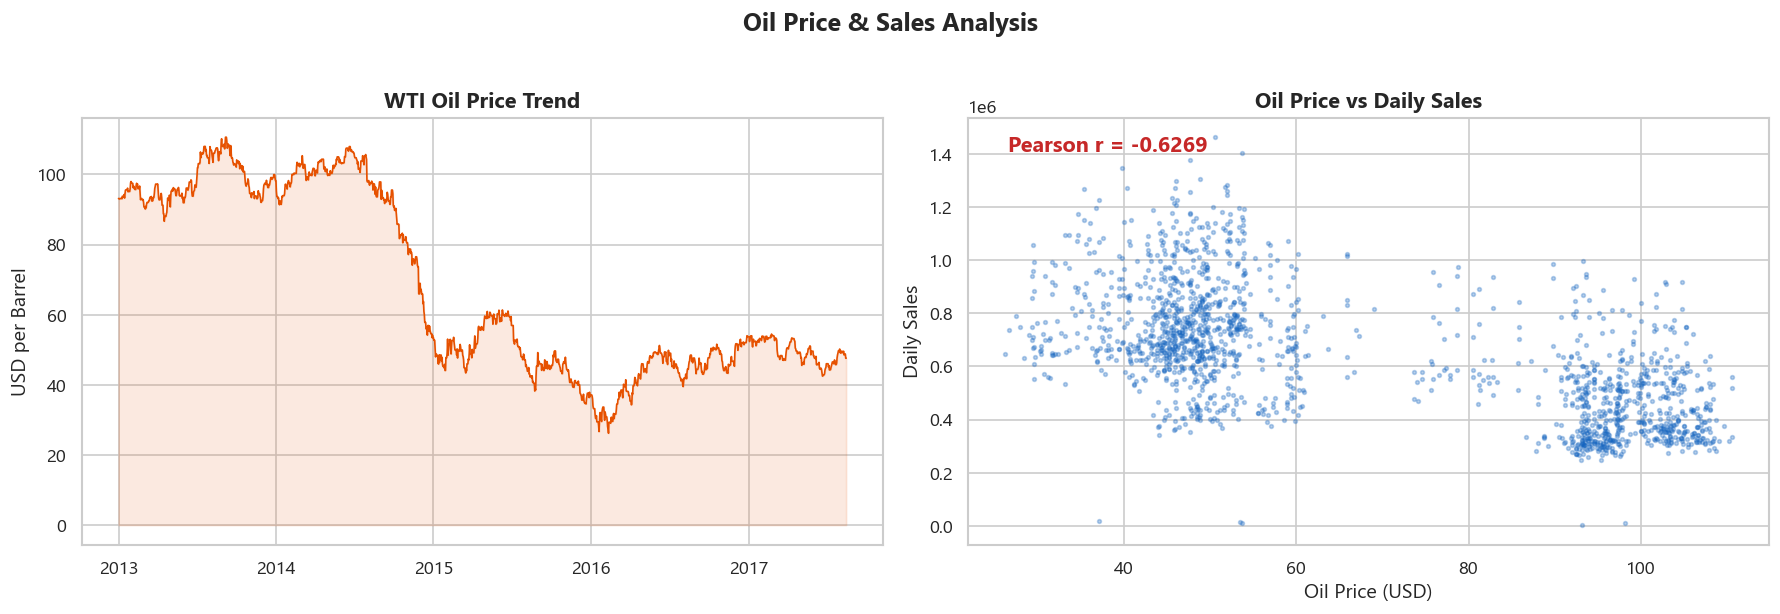

In [16]:
oil = df_oil.copy()
oil['dcoilwtico'] = oil['dcoilwtico'].ffill().bfill()

daily_sales = df_train.groupby('date', as_index=False)['unit_sales'].sum()
daily_sales['date'] = pd.to_datetime(daily_sales['date'])
oil_merged = daily_sales.merge(oil, on='date', how='left')
oil_merged['dcoilwtico'] = oil_merged['dcoilwtico'].ffill()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Oil trend
axes[0].plot(oil_merged['date'], oil_merged['dcoilwtico'], color='#e65100', linewidth=1)
axes[0].fill_between(oil_merged['date'], oil_merged['dcoilwtico'], alpha=0.12, color='#e65100')
axes[0].set_title('WTI Oil Price Trend')
axes[0].set_ylabel('USD per Barrel')
axes[0].xaxis.set_major_locator(mdates.YearLocator())
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Scatter
axes[1].scatter(oil_merged['dcoilwtico'], oil_merged['unit_sales'],
                alpha=0.3, s=5, color='#1565c0')
corr = oil_merged[['dcoilwtico','unit_sales']].corr().iloc[0,1]
axes[1].set_title('Oil Price vs Daily Sales')
axes[1].set_xlabel('Oil Price (USD)'); axes[1].set_ylabel('Daily Sales')
axes[1].annotate(f'Pearson r = {corr:.4f}', xy=(0.05, 0.92), xycoords='axes fraction',
                 fontsize=13, fontweight='bold', color='#c62828')

fig.suptitle('Oil Price & Sales Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig(fig, '06a_oil_trend.png')


### 8.2 Rolling 60-Day Correlation: Oil Price vs Sales

**Key Findings:**
- The oil–sales relationship is **non-stationary** — the 60-day rolling correlation oscillates between **–0.6** and **+0.7**
- Strong negative periods (mid-2014, late 2015) coincide with oil price crashes
- **Positive spikes** (mid-2015) indicate temporary regime changes where oil and sales moved together
- This instability suggests **rolling window features** of oil price are more valuable than raw price alone


💾 Saved → 06b_oil_rolling_corr.png


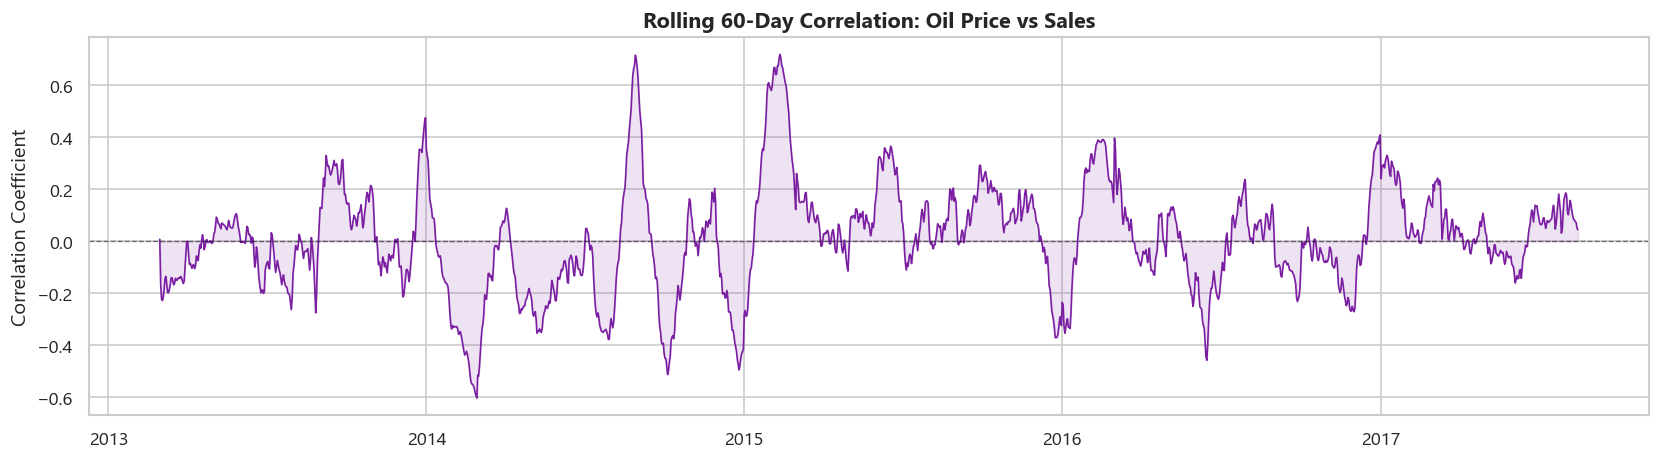

In [17]:
# Rolling correlation reveals how the relationship changes over time
roll_corr = oil_merged.set_index('date')[['dcoilwtico','unit_sales']].rolling(60).corr()
roll_corr = roll_corr.unstack()['dcoilwtico']['unit_sales'].dropna()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(roll_corr.index, roll_corr.values, color='#7b1fa2', linewidth=1)
ax.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.fill_between(roll_corr.index, roll_corr.values, alpha=0.12, color='#7b1fa2')
ax.set_title('Rolling 60-Day Correlation: Oil Price vs Sales')
ax.set_ylabel('Correlation Coefficient')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
save_fig(fig, '06b_oil_rolling_corr.png')


---

## 9️⃣ Holiday & Event Impact on Sales

Ecuador has a complex holiday calendar with **National, Regional, Local, and Transferred** holidays that affect demand differently.


💾 Saved → 07_holiday_impact.png


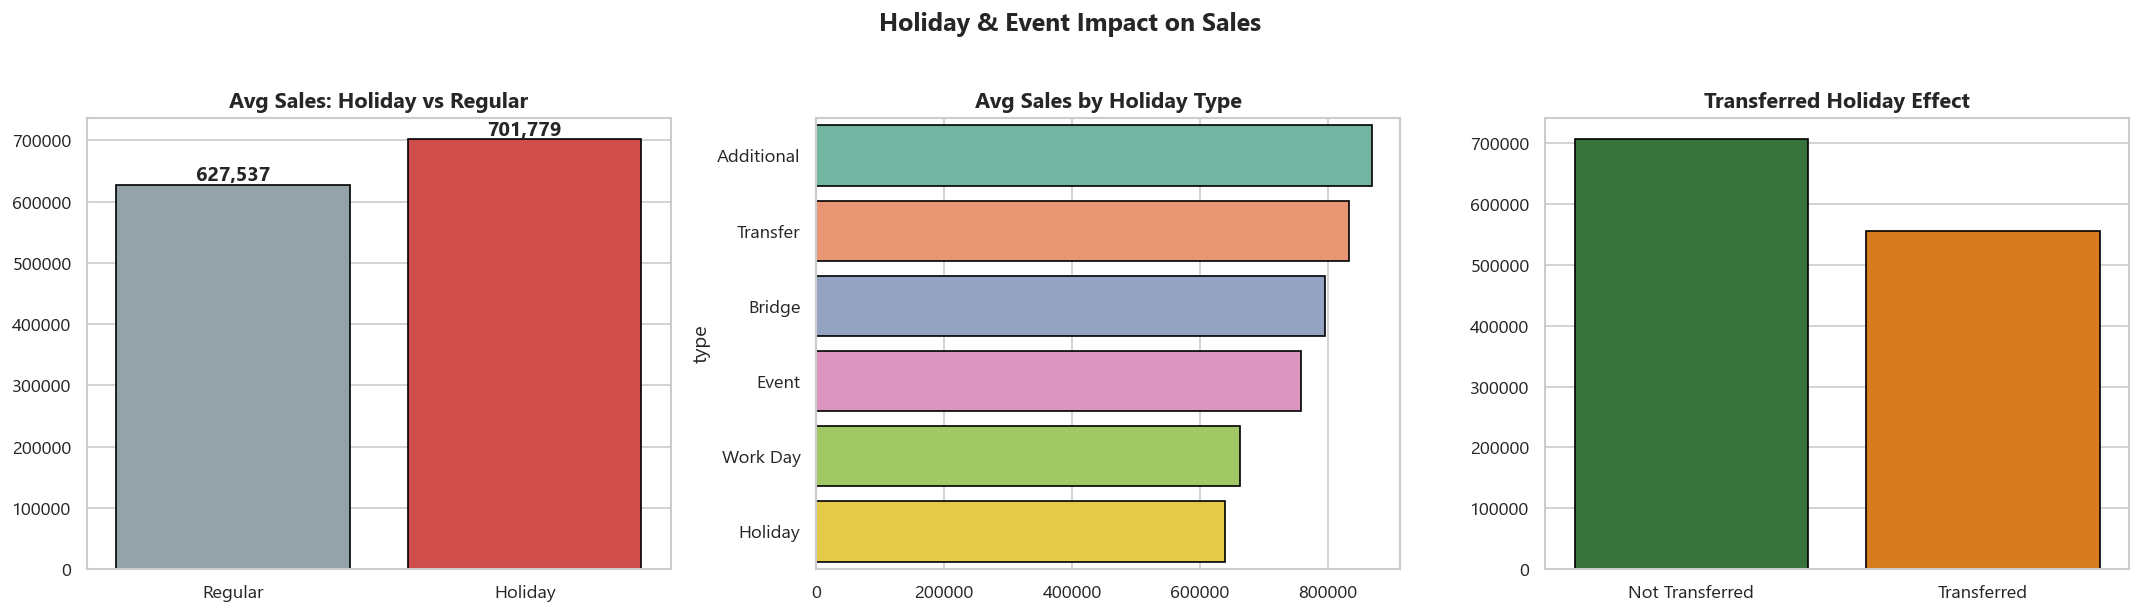

In [18]:
daily_h = df_train.groupby('date')['unit_sales'].sum().reset_index()
daily_h['date'] = pd.to_datetime(daily_h['date'])

hol = df_holidays.copy()
hol['date'] = pd.to_datetime(hol['date'])
daily_h = daily_h.merge(hol, on='date', how='left')
daily_h['is_holiday'] = daily_h['type'].notna()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Holiday vs Regular
hol_avg = daily_h.groupby('is_holiday')['unit_sales'].mean()
lbl_h = ['Regular', 'Holiday']
sns.barplot(x=lbl_h, y=hol_avg.values, hue=lbl_h,
            palette=['#90a4ae','#e53935'], ax=axes[0], edgecolor='black', legend=False)
axes[0].set_title('Avg Sales: Holiday vs Regular')
for i, v in enumerate(hol_avg.values):
    axes[0].text(i, v, f'{v:,.0f}', ha='center', va='bottom', fontweight='bold')

# 2. By holiday type
hol_only = daily_h[daily_h['is_holiday']]
htype = hol_only.groupby('type')['unit_sales'].mean().sort_values(ascending=False)
sns.barplot(x=htype.values, y=htype.index, hue=htype.index,
            palette='Set2', ax=axes[1], edgecolor='black', legend=False)
axes[1].set_title('Avg Sales by Holiday Type')

# 3. Transferred effect
trans_avg = hol_only.groupby('transferred')['unit_sales'].mean()
lbl_t = ['Not Transferred', 'Transferred']
sns.barplot(x=lbl_t, y=trans_avg.values, hue=lbl_t,
            palette=['#2e7d32','#f57c00'], ax=axes[2], edgecolor='black', legend=False)
axes[2].set_title('Transferred Holiday Effect')

fig.suptitle('Holiday & Event Impact on Sales', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig(fig, '07_holiday_impact.png')


---

## 🔟 Transaction Patterns & Store Footfall

Transaction counts serve as a direct proxy for **customer footfall** — the number of unique checkout events per store per day.


💾 Saved → 08_transactions.png


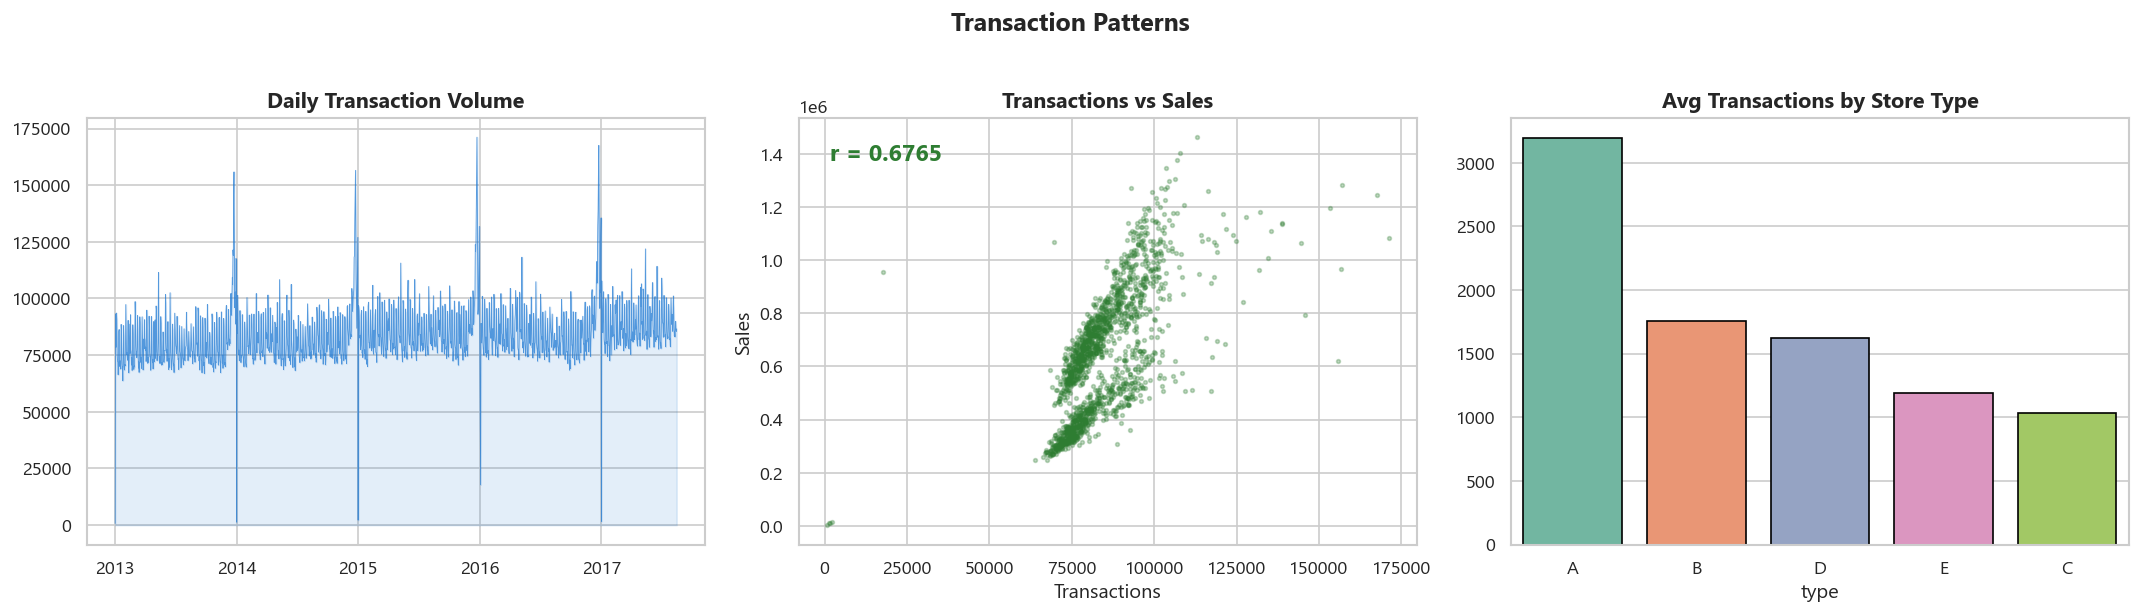

In [19]:
trans = df_trans.copy()
daily_trans = trans.groupby('date')['transactions'].sum().reset_index()

daily_st = df_train.groupby('date', as_index=False)['unit_sales'].sum()
daily_st['date'] = pd.to_datetime(daily_st['date'])
merged_t = daily_st.merge(daily_trans, on='date', how='inner')
trans_stores = trans.merge(df_stores[['store_nbr','type']], on='store_nbr', how='left')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Volume timeline
axes[0].plot(daily_trans['date'], daily_trans['transactions'],
             linewidth=0.5, color='#1976d2', alpha=0.7)
axes[0].fill_between(daily_trans['date'], daily_trans['transactions'],
                     alpha=0.12, color='#1976d2')
axes[0].set_title('Daily Transaction Volume')
axes[0].xaxis.set_major_locator(mdates.YearLocator())
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# 2. Correlation scatter
axes[1].scatter(merged_t['transactions'], merged_t['unit_sales'],
                alpha=0.3, s=5, color='#2e7d32')
r = merged_t[['transactions','unit_sales']].corr().iloc[0,1]
axes[1].set_title('Transactions vs Sales')
axes[1].set_xlabel('Transactions'); axes[1].set_ylabel('Sales')
axes[1].annotate(f'r = {r:.4f}', xy=(0.05, 0.9), xycoords='axes fraction',
                 fontsize=14, fontweight='bold', color='#2e7d32')

# 3. By store type
type_t = trans_stores.groupby('type')['transactions'].mean().sort_values(ascending=False)
sns.barplot(x=type_t.index, y=type_t.values, hue=type_t.index,
            palette='Set2', ax=axes[2], edgecolor='black', legend=False)
axes[2].set_title('Avg Transactions by Store Type')

fig.suptitle('Transaction Patterns', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig(fig, '08_transactions.png')


---

## 1️⃣1️⃣ Daily-Level Feature Correlation Heatmap

Understanding pairwise correlations between daily-aggregated features helps identify multicollinearity and the most predictive signals.


C:\Users\OKCode\AppData\Local\Temp\ipykernel_9892\1982692631.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  promo_rate=('onpromotion', lambda x: x.fillna(False).astype(bool).mean())
C:\Users\OKCode\AppData\Local\Temp\ipykernel_9892\1982692631.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  promo_rate=('onpromotion', lambda x: x.fillna(False).astype(bool).mean())
C:\Users\OKCode\AppData\Local\Temp\ipykernel_9892\1982692631.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future ver

💾 Saved → 09_correlation_heatmap.png


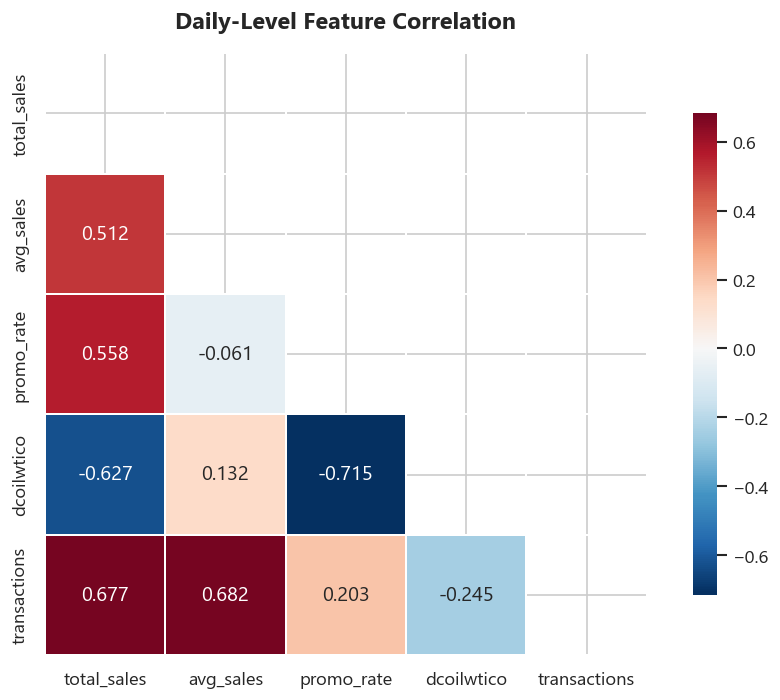

In [20]:
# Build daily feature table
daily_agg = df_train.groupby('date').agg(
    total_sales=('unit_sales', 'sum'),
    avg_sales=('unit_sales', 'mean'),
    promo_rate=('onpromotion', lambda x: x.fillna(False).astype(bool).mean())
).reset_index()
daily_agg['date'] = pd.to_datetime(daily_agg['date'])

oil_c = df_oil.copy()
oil_c['dcoilwtico'] = oil_c['dcoilwtico'].ffill().bfill()
trans_c = df_trans.groupby('date', as_index=False)['transactions'].sum()

corr_df = (daily_agg
    .merge(oil_c, on='date', how='left')
    .merge(trans_c, on='date', how='left'))
corr_df['dcoilwtico'] = corr_df['dcoilwtico'].ffill()

cols = ['total_sales', 'avg_sales', 'promo_rate', 'dcoilwtico', 'transactions']
matrix = corr_df[cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(matrix, dtype=bool))
sns.heatmap(matrix, mask=mask, annot=True, fmt='.3f',
            cmap='RdBu_r', center=0, linewidths=1, ax=ax,
            square=True, cbar_kws={'shrink': 0.8})
ax.set_title('Daily-Level Feature Correlation', fontweight='bold', fontsize=14, pad=15)
plt.tight_layout()
save_fig(fig, '09_correlation_heatmap.png')


---

## 1️⃣2️⃣ Key EDA Findings & Preprocessing Implications

### 📊 Distribution & Outlier Findings
| Finding | Value | Action |
|---------|-------|--------|
| Median sales | **4.0 units** | Use `log1p(y)` target for RMSLE |
| P99 outlier | **72.2 units** | Consider clipping at P99 |
| Negative sales | Present (~3.8% of records) | Clip to 0 or flag as returns |

### 📈 Temporal & Seasonality Findings
| Finding | Value | Action |
|---------|-------|--------|
| Sunday peak | 830K avg daily | Create `is_weekend` feature |
| December peak | 830K avg monthly | Create cyclical `sin_month`/`cos_month` |
| YoY growth | +15–49% annually | Include `year` as feature |
| April 2016 dip | Earthquake event | Create `is_earthquake_period` flag |

### 🏪 Store & Family Findings
| Finding | Value | Action |
|---------|-------|--------|
| Quito dominance | 50%+ of revenue | Target-encode `city` |
| Types A & D | Equal revenue leaders | Keep `store_type` as feature |
| GROCERY I + BEVERAGES | 50%+ of sales | Focus model accuracy on these families |
| Perishable ratio | 31.9% | Use 1.25× weight in NWRMSLE |

### 💡 Correlation & Feature Engineering Insights
| Feature Pair | Correlation | Interpretation |
|--------------|-------------|----------------|
| Oil → Total Sales | **–0.627** | Strong macro-economic inverse driver |
| Oil → Promo Rate | **–0.715** | Low oil → more promotions |
| Transactions → Sales | **+0.677** | Strong footfall proxy |
| Transactions → Avg Sales | **+0.682** | Higher footfall = higher per-store sales |
| Promo Rate → Total Sales | **+0.558** | Promotions drive aggregate volume |

### ⚠️ Data Quality Issues Requiring Preprocessing
1. **Oil price NaNs** (~7% missing on weekends/holidays) → Forward-fill + Backward-fill
2. **Promotion NaNs** (pre-2014 missing entirely) → Fill with `False`
3. **Negative sales** (returns) → Clip to 0 for demand forecasting
4. **Transferred holidays** → Must remap to actual celebration date

---

**➡️ Next Notebook:** Open `03_data_preprocessing.ipynb` to clean, merge, and optimize the datasets based on these findings.
